# Validation Pipeline Sketch V3
## 0. Imports and Set-Up:

### 0.1 Imports, Seed-Setting, Plotting-Helper-Function:

In [103]:
import multiprocessing
import random
import warnings

from pathlib import Path
from joblib import Parallel, delayed
from itertools import product

import numpy as np
from numpy.linalg import svd 

import pandas as pd
from pandas.plotting import parallel_coordinates

from sklearn.cluster import KMeans, SpectralClustering, AgglomerativeClustering
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import adjusted_rand_score, pairwise_distances
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, normalize, FunctionTransformer, StandardScaler
from sklearn.model_selection import ParameterSampler

from umap import UMAP

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import seaborn as sns

In [78]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
col_pal = sns.color_palette("rainbow", n_colors=8)

sns.set_theme(
    style="whitegrid",
    palette=col_pal,
    font_scale=1.2,
    rc={
        "axes.edgecolor": ".2",
        "grid.color": ".8",
        "grid.linewidth": 0.8,
        "figure.figsize": (8, 5),
        "axes.prop_cycle": plt.cycler(color=col_pal)
    }
)

sns.set_context("notebook", rc={"lines.linewidth": 2, "font.size": 14})

### 0.2 Helper Functions:

In [4]:
def plot_dim_reduced_clustering(
    X: np.ndarray, 
    clusters: np.ndarray, 
    method: str = 'PCA', 
    perplexity: int = 30, 
    n_neighbors: int = 15, 
    min_dist: float = 0.1,
    ax: plt.Axes = None, 
    show: bool = True
) -> plt.Axes:
    """
    Plot a 2D embedding of the data colored by cluster assignments.

    :param X: the input data matrix to be reduced and plotted (n_samples, n_features)
    :param clusters: cluster labels for each sample (n_samples,)
    :param method: dimensionality reduction method to use; either 'PCA' or 'tSNE'
    :param ax: a matplotlib axes object to be plotted on
    :param show: controls whether to call plt.show()

    :return: plt.Axes if show = False, otherwise displays a scatter plot with the samples colored by cluster assignment
    """
    # dimensionality reduction
    if method == 'PCA':
        X_red = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(X)
    elif method == 'tSNE':
        X_red = TSNE(
            n_components=2,
            random_state=RANDOM_SEED,
            perplexity=perplexity
        ).fit_transform(X)
    elif method == 'UMAP':
        X_red = UMAP(
            n_components=2, 
            n_neighbors=n_neighbors, 
            min_dist=min_dist, 
            random_state=RANDOM_SEED  # throws a warning
        ).fit_transform(X)
    else:
        raise ValueError(f"Unknown dimensionality reduction method {method}. Use one of 'PCA', 'tSNE', or 'UMAP'.")

    # build discrete colormap for clusters
    unique_clusters = np.unique(clusters)
    base_cmap = plt.get_cmap('Set1', len(unique_clusters))
    color_dict = {lab: base_cmap(i) for i, lab in enumerate(unique_clusters)}

    # plot points
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 8))
    point_colors = [color_dict[lab] for lab in clusters]
    ax.scatter(X_red[:, 0], X_red[:, 1], c=point_colors, s=10, alpha=0.8)

    # handle legend
    for lab in unique_clusters:
        ax.scatter([], [], c=[color_dict[lab]], label=f"cluster {lab}", s=50, alpha=0.8)
        
    ax.legend(loc='lower right', frameon=False)

    # titles & axis labels
    if method == 'PCA':
        ax.set(
            title="PCA of TCGA Pan-Cancer gene expression",
            xlabel="PCA 1",
            ylabel="PCA 2"
        )
    elif method == 'tSNE':
        ax.set(
            title="t-SNE of TCGA Pan-Cancer gene expression",
            xlabel="t-SNE 1",
            ylabel="t-SNE 2"
        )
    else:
        ax.set(
            title="UMAP of TCGA Pan-Cancer gene expression",
            xlabel="UMAP 1",
            ylabel="UMAP 2"
        )

    if show:
        plt.tight_layout()
        plt.show()
    else:
        return ax

In [5]:
def subsample_indices(n_samples: int, ratio: float = 0.8, random_state: int = None) -> tuple[np.ndarray, np.ndarray]:
    """
    draw a subsample of indices of size floor(ratio * n_samples).
    
    :param n_samples: total number of samples in data frame.
    :param ratio: ratio for subsampling, between 0 and 1. 
    :param random_state: random seed for rng.
    
    :return:
        train_idx: 1D array of length floor(ratio * n_samples).
        test_idx: the complement indices (length = n_samples - len(train_idx)).
    """
    rng = np.random.RandomState(random_state)
    all_idx = np.arange(n_samples)
    train_size = int(np.float64(ratio * n_samples))
    
    train_idx = rng.choice(all_idx, size=train_size, replace=False)
    test_idx = np.setdiff1d(all_idx, train_idx)
    
    return train_idx, test_idx

In [6]:
def update_consensus_count(C: np.ndarray, labels_full: np.ndarray) -> None:
    """
    increment C[i,j] by 1 for every pair i,j that share the same cluster label.
    
    :param C: consensus matrix.
    :param labels_full: 1D array length = n_samples, where each entry is an integer cluster ID.
    
    :return: None (C is updated in place)
    """
    for cluster_id in np.unique(labels_full):
        members = np.where(labels_full == cluster_id)[0]
        
        for i in members:
            C[i, members] += 1
    
    return None

### 0.3 Data Import:

In [27]:
data_dir = Path('./data/TCGA-PANCAN-HiSeq-801x20531')
data_fp = data_dir / 'data.csv'
labels_fp = data_dir / 'labels.csv'

labels = pd.read_csv(labels_fp, header=None, skiprows=1)

sample = pd.read_csv(data_fp, header=None, skiprows=1, nrows=100, low_memory=False)
numeric_cols = [
    col
    for col in sample.columns
    if pd.to_numeric(sample[col], errors='coerce').notna().all()
]

print(f"found {len(numeric_cols)} numeric cols out of {len(sample.columns)}")

data = pd.read_csv(
    data_fp,
    header=None,
    usecols=numeric_cols,
    skiprows=1, 
    dtype=float,
    low_memory=False
)

le = LabelEncoder()
y = le.fit_transform(labels[1])

X = data.values

print("X shape:", X.shape, " |  y shape:", y.shape)

found 20531 numeric cols out of 20532
X shape: (801, 20531)  |  y shape: (801,)


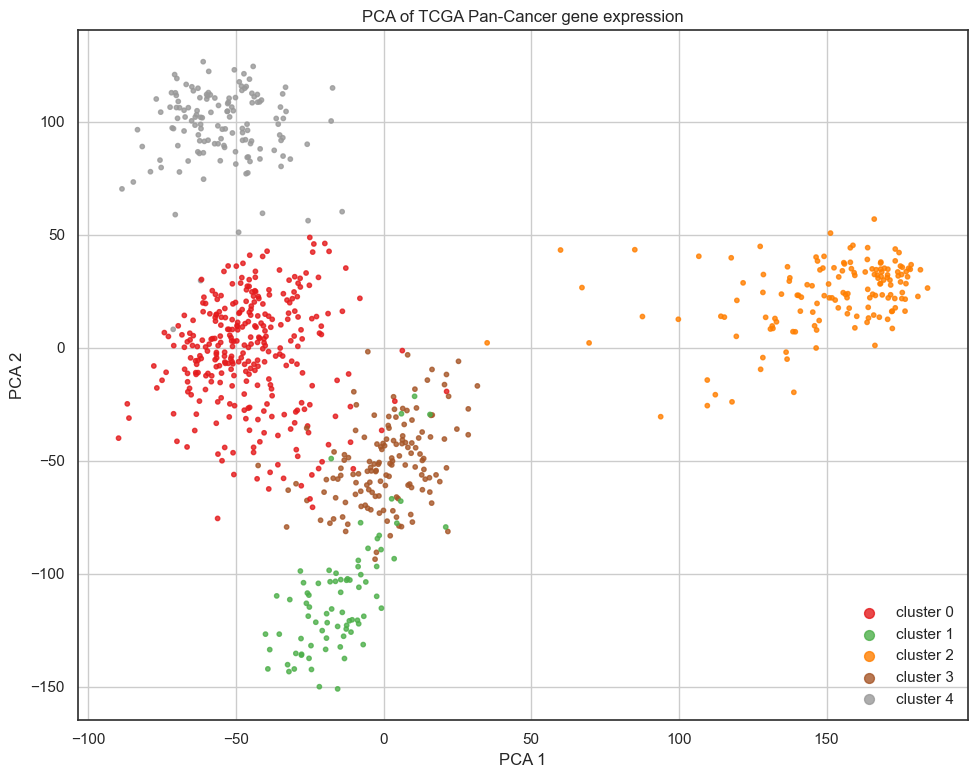

In [275]:
plot_dim_reduced_clustering(X, y, method='PCA')

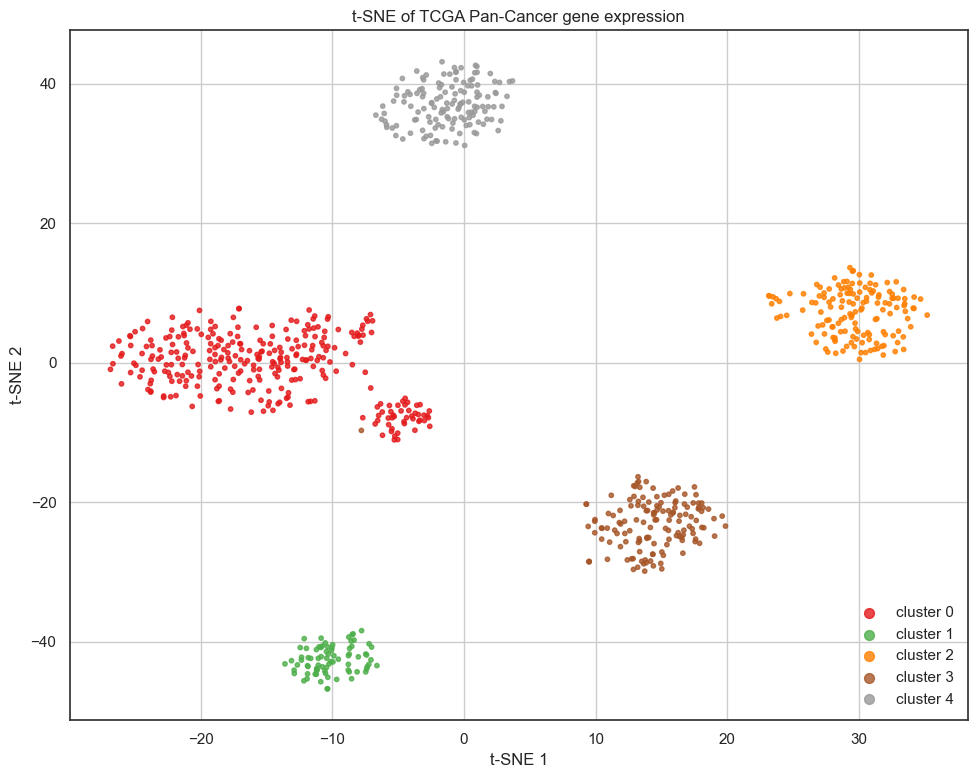

In [276]:
plot_dim_reduced_clustering(X, y, method='tSNE')

/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


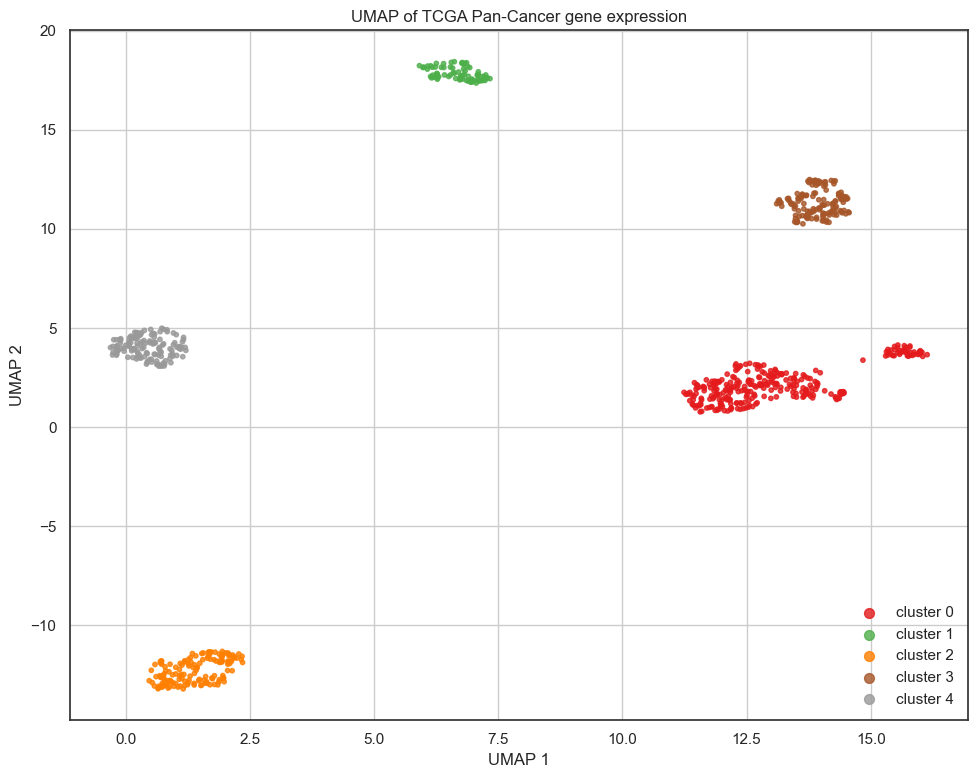

In [307]:
plot_dim_reduced_clustering(X, y, method='UMAP')

Normalize the data:

In [17]:
X_norm = normalize(X)

Compute PCA s.t. 90% of variance is captured:

In [59]:
X_norm_reduc = PCA(n_components=0.9, svd_solver='full', random_state=RANDOM_SEED).fit_transform(X_norm)

In [60]:
X_norm_reduc.shape

(801, 311)

In [29]:
# # save
# np.save(file='./data/TCGA-PANCAN-HiSeq-PCA/X_norm_reduc', arr=X_norm_reduc)

# # load
# X = np.load('./data/TCGA-PANCAN-HiSeq-PCA/X_norm_reduc.npy')

---

## 1. Validation Function:

In [69]:
def get_preprocessing(
    normalization_method: str = 'normal',
    dim_red_method: str = 'PCA', 
    n_components: int = 50, 
    perplexity: int = 30, 
    n_neighbors: int = 15, 
    min_dist: float = 0.1
) -> Pipeline:
    """
    perform data normalization and dimensionality reduction.

    :param normalization_method: normalization method to be applied; one of 'raw', 'normal', or 'l1p'
    :param dim_red_method: dimensionality reduction technique to use; one of 'raw', 'PCA', 'tSNE', or 'UMAP'
    :param n_components: target number of components for dimensionality reduction
    :param perplexity: perplexity parameter for t-SNE (only if dim_red_method == 'tSNE')
    :param n_neighbors: number of neighbors for UMAP (only if dim_red_method == 'UMAP')
    :param min_dist: minimum distance between points in UMAP embedding (only if dim_red_method == 'UMAP')

    :return: sklearn Pipeline object
    """
    steps = []
    # normalization
    if normalization_method == 'raw':
        steps.append(('norm', FunctionTransformer(lambda X: X)))
    elif normalization_method == 'normal':
        steps.append(('norm', StandardScaler()))
    elif normalization_method == 'l1p':
        steps.append(('norm', FunctionTransformer(np.log1p)))
    # dim reduction
    if dim_red_method == 'raw':
        steps.append(('dr', FunctionTransformer(lambda X: X)))
    elif dim_red_method == 'PCA':
        steps.append(('dr', PCA(n_components=n_components, random_state=RANDOM_SEED)))
    elif dim_red_method == 'tSNE':
        steps.append(('dr', TSNE(n_components=n_components, perplexity=perplexity, random_state=RANDOM_SEED)))
    elif dim_red_method == 'UMAP':
        steps.append(('dr', UMAP(n_components=n_components, n_neighbors=n_neighbors, min_dist=min_dist, random_state=RANDOM_SEED)))
        
    return Pipeline(steps)

In [66]:
def clustering_pipeline(
    X: np.ndarray, 
    k: int, 
    cluster_method: str = 'kmeans',
    linkage: str = 'ward', 
    gamma: float = 1.0
) -> np.ndarray:
    """
    cluster data.

    :param X: input data array of shape (n_samples, n_features)
    :param k: number of clusters to form
    :param cluster_method: clustering algorithm to apply; one of 'kmeans', 'hierarchical', or 'spectral'
    :param linkage: type of linkage to use for agglomerative clustering; one of 'ward', 'complete', 'average', or 'single'
    :param gamma: kernel coefficient for RBF kernel used in constructing the affinity matrix for spectral clustering (only if cluster_method == 'spectral')

    :return: array of cluster labels, one label per input sample
    """
    if cluster_method == 'kmeans':
        clusters = KMeans(n_clusters=k, random_state=RANDOM_SEED).fit_predict(X)
    elif cluster_method == 'hierarchical':
        clusters = AgglomerativeClustering(n_clusters=k, linkage=linkage).fit_predict(X)
    elif cluster_method == 'spectral':
        clusters = SpectralClustering(n_clusters=k, gamma=gamma, random_state=RANDOM_SEED).fit_predict(X)
    else:
        raise ValueError(f"Unknown clustering method {cluster_method}. Use one of 'kmeans', 'hierarchical', or 'spectral'.")
    
    return clusters

In [ ]:
def validate_clustering(X: np.ndarray, K: int, B: int = 20) -> pd.DataFrame:
    """
    perform data normalization, dimensionality reduction, and clustering.

    :param X: input data array of shape (n_samples, n_features)
    :param K: max K to validate
    :param B: validation iterations

    :return: array of cluster labels, one label per input sample
    """
    num_cores = max(1, multiprocessing.cpu_count() - 1)
    n_samples, p = X.shape
    
    D2 = pairwise_distances(X, metric='sqeuclidean')
    median_d2 = np.median(D2[np.triu_indices_from(D2, k=1)])
    gamma0 = 1.0 / (2.0 * median_d2)
    
    search_space = {
        'kmeans': {'linkage': [None], 'gamma': [None]},
        'hierarchical':{'linkage': ['ward', 'complete', 'average', 'single'], 'gamma': [None]},
        'spectral': {'linkage': [None], 'gamma': np.logspace(np.log10(gamma0) - 1, np.log10(gamma0) + 1, num=3)},
    }

    def _validation_iter(current_iter: int, k: int, cluster_method: str, linkage: str, gamma:float, rho: float = 0.8):
        # seed RNG so choices are reproducible
        rnd = random.Random(current_iter + k * B)

        # draw a random preprocessing pipeline
        norm_method = rnd.choice(['raw', 'normal', 'l1p'])
        dimred_method = rnd.choice(['raw', 'PCA', 'tSNE', 'UMAP'])
        
        n_components = rnd.randint(5, 50)
        perplexity = n_neighbors = None

        if dimred_method == 'tSNE':
            n_components = rnd.randint(2, 3)
            perplexity = rnd.randint(5, 50)
        elif dimred_method == 'UMAP':
            n_components = rnd.randint(2, 50)
            n_neighbors = rnd.randint(5, 50)

        # subsample indices
        A_train, A_test = subsample_indices(n_samples, ratio=rho, random_state=current_iter)
        B_idx, _ = subsample_indices(n_samples, ratio=rho, random_state=current_iter + B)

        # apply the random preprocessing to each split
        preproc = get_preprocessing(norm_method, dimred_method, n_components, perplexity, n_neighbors)
        X_Atrain = preproc.fit_transform(X[A_train])
        X_Atest = preproc.fit_transform(X[A_test])
        X_B = preproc.fit_transform(X[B_idx])

        # cluster on preprocessed data
        labels_A_train = clustering_pipeline(X=X_Atrain, k=k, cluster_method=cluster_method, linkage=linkage, gamma=gamma)
        labels_A_test = clustering_pipeline(X=X_Atest, k=k, cluster_method=cluster_method, linkage=linkage, gamma=gamma)
        labels_B = clustering_pipeline(X=X_B, k=k, cluster_method=cluster_method, linkage=linkage, gamma=gamma)

        # model-explorer ARI
        _, pos_A, pos_B = np.intersect1d(A_train, B_idx, return_indices=True)
        ari_model_exp  = adjusted_rand_score(labels_A_train[pos_A], labels_B[pos_B])

        # predictive ARI via RF
        rf_A = RandomForestClassifier(
            n_estimators=100,
            max_depth=p,
            max_features=int(np.round(np.sqrt(p))),
            random_state=current_iter
        )
        rf_A.fit(X_Atrain, labels_A_train)
        labels_A_test_pred = rf_A.predict(X_Atest)
        ari_pred = adjusted_rand_score(labels_A_test, labels_A_test_pred)

        return ari_model_exp, ari_pred

    # loop over k and parallelize
    records = []
    for k in range(2, K + 1):
        for cluster_method, params in search_space.items():
            _, values = zip(*params.items())
            
            for combo in product(*values):
                linkage, gamma = combo  # gamma or linkage may be None
            
                print(f'validating clustering method \'{cluster_method}\' with linkage: \'{linkage}\' and gamma={gamma} at k={k} ...')
            
                results = Parallel(n_jobs=num_cores)(
                    delayed(_validation_iter)(current_iter=s, k=k, cluster_method=cluster_method, linkage=linkage, gamma=gamma) for s in range(B)
                )
                
                # unzip and average
                model_exp_aris, pred_aris = zip(*results)
                model_exp_ari = np.mean(model_exp_aris)
                pred_ari = np.mean(pred_aris)
                
                records.append({
                'method': cluster_method,
                'linkage': linkage,
                'gamma': gamma,
                'k': k,
                'model_explorer_ARI': model_exp_ari,
                'predictive_ARI': pred_ari
            })

    return pd.DataFrame.from_records(records)

In [101]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning


In [102]:
results_df = validate_clustering(X=X, K=7, B=20)

validating clustering method 'kmeans' with linkage: 'None' and gamma=None at k=2 ...


Exception ignored in: <function ResourceTracker.__del__ at 0x104845620>
Traceback (most recent call last):
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102469620>
Traceback (most recent call last):
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
Chi

validating clustering method 'hierarchical' with linkage: 'ward' and gamma=None at k=2 ...
validating clustering method 'hierarchical' with linkage: 'complete' and gamma=None at k=2 ...
validating clustering method 'hierarchical' with linkage: 'average' and gamma=None at k=2 ...
validating clustering method 'hierarchical' with linkage: 'single' and gamma=None at k=2 ...
validating clustering method 'spectral' with linkage: 'None' and gamma=6.727239749906794e-07 at k=2 ...
validating clustering method 'spectral' with linkage: 'None' and gamma=6.727239749906794e-06 at k=2 ...
validating clustering method 'spectral' with linkage: 'None' and gamma=6.727239749906794e-05 at k=2 ...
validating clustering method 'kmeans' with linkage: 'None' and gamma=None at k=3 ...
validating clustering method 'hierarchical' with linkage: 'ward' and gamma=None at k=3 ...
validating clustering method 'hierarchical' with linkage: 'complete' and gamma=None at k=3 ...
validating clustering method 'hierarchical' 

In [108]:
df = results_df

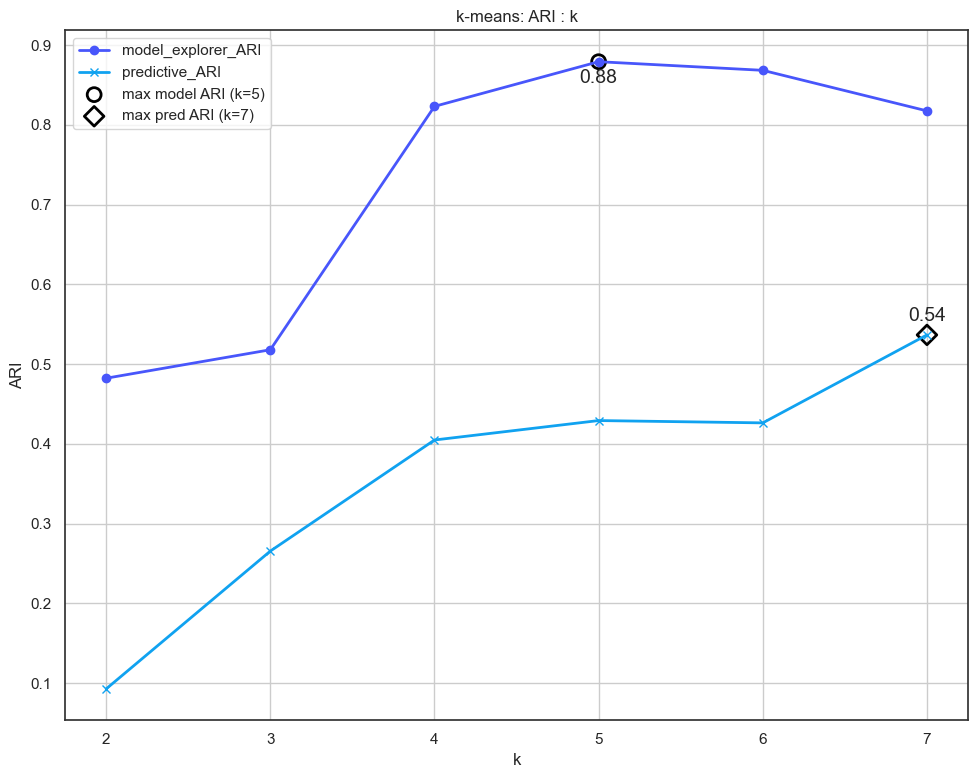

In [ ]:
# filter for kmeans
df_km = df[df['method'] == 'kmeans'].sort_values('k')

# find the k’s with lowest ARIs
max_mod = df_km.loc[df_km['model_explorer_ARI'].idxmax()]
max_pred = df_km.loc[df_km['predictive_ARI'].idxmax()]

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(df_km['k'], df_km['model_explorer_ARI'], marker='o', label='model_explorer_ARI')
ax.plot(df_km['k'], df_km['predictive_ARI'], marker='x', label='predictive_ARI')

ax.scatter(
    max_mod['k'], max_mod['model_explorer_ARI'], 
    s=100, edgecolor='black', facecolor='none', linewidth=2,
    label=f"max model ARI (k={int(max_mod['k'])})"
)
ax.scatter(
    max_pred['k'], max_pred['predictive_ARI'], 
    s=100, marker='D', edgecolor='black', facecolor='none', linewidth=2,
    label=f"max pred ARI (k={int(max_pred['k'])})"
)

# annotate values
ax.annotate(
    f"{max_mod['model_explorer_ARI']:.2f}", 
    (max_mod['k'], max_mod['model_explorer_ARI']),
    xytext=(0, -15), textcoords='offset points', ha='center'
)
ax.annotate(
    f"{max_pred['predictive_ARI']:.2f}", 
    (max_pred['k'], max_pred['predictive_ARI']),
    xytext=(0, 10), textcoords='offset points', ha='center'
)

ax.set_xlabel('k')
ax.set_ylabel('ARI')
ax.set_title('k-means: ARI : k')
ax.set_xticks(df_km['k'])
ax.legend()
plt.tight_layout()
plt.show()

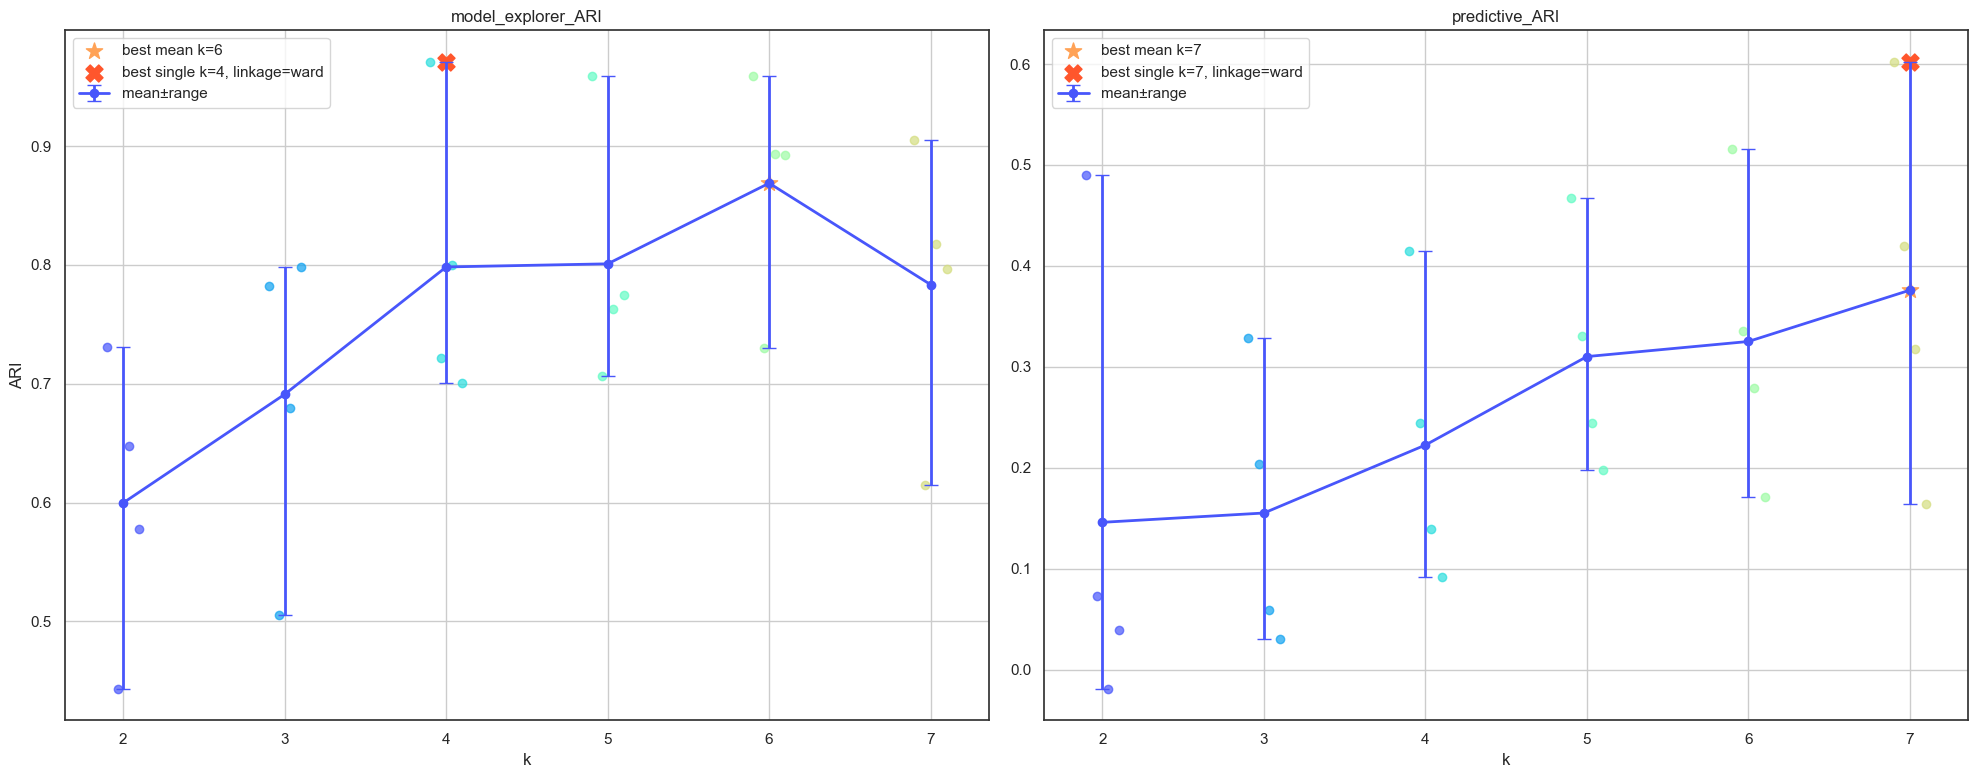

In [128]:
hier = df[df['method'] == 'hierarchical']
ks = sorted(hier['k'].unique())

mean_model = hier.groupby('k')['model_explorer_ARI'].mean()
min_model  = hier.groupby('k')['model_explorer_ARI'].min()
max_model  = hier.groupby('k')['model_explorer_ARI'].max()
k_best_mean_model = mean_model.idxmax()
best_single_model  = hier.loc[hier['model_explorer_ARI'].idxmax()]

mean_pred = hier.groupby('k')['predictive_ARI'].mean()
min_pred  = hier.groupby('k')['predictive_ARI'].min()
max_pred  = hier.groupby('k')['predictive_ARI'].max()
k_best_mean_pred = mean_pred.idxmax()
best_single_pred = hier.loc[hier['predictive_ARI'].idxmax()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharex=True)

for k in ks:
    vals = hier[hier['k'] == k]['model_explorer_ARI'].values
    jitter = np.linspace(-0.1, 0.1, len(vals))
    ax1.scatter(np.full_like(vals, k) + jitter, vals, alpha=0.7)

err_low  = mean_model - min_model
err_high = max_model  - mean_model
ax1.errorbar(ks, mean_model, yerr=[err_low, err_high], fmt='o-', capsize=5, label='mean±range')

ax1.scatter(
    k_best_mean_model, mean_model[k_best_mean_model], 
    s=150, marker='*', label=f'best mean k={k_best_mean_model}'
)

ax1.scatter(
    best_single_model['k'], best_single_model['model_explorer_ARI'], 
    s=150, marker='X', label=f'best single k={best_single_model["k"]}, linkage={best_single_model["linkage"]}'
)

ax1.set_title('model_explorer_ARI')
ax1.set_xlabel('k')
ax1.set_ylabel('ARI')
ax1.legend()

for k in ks:
    vals = hier[hier['k'] == k]['predictive_ARI'].values
    jitter = np.linspace(-0.1, 0.1, len(vals))
    ax2.scatter(np.full_like(vals, k) + jitter, vals, alpha=0.7)

err_low  = mean_pred - min_pred
err_high = max_pred  - mean_pred
ax2.errorbar(ks, mean_pred, yerr=[err_low, err_high], fmt='o-', capsize=5, label='mean±range')

ax2.scatter(
    k_best_mean_pred, mean_pred[k_best_mean_pred], 
    s=150, marker='*', label=f'best mean k={k_best_mean_pred}'
)

ax2.scatter(
    best_single_pred['k'], best_single_pred['predictive_ARI'], 
    s=150, marker='X', label=f'best single k={best_single_pred["k"]}, linkage={best_single_pred["linkage"]}'
)

ax2.set_title('predictive_ARI')
ax2.set_xlabel('k')
ax2.legend()

plt.tight_layout()
plt.show()

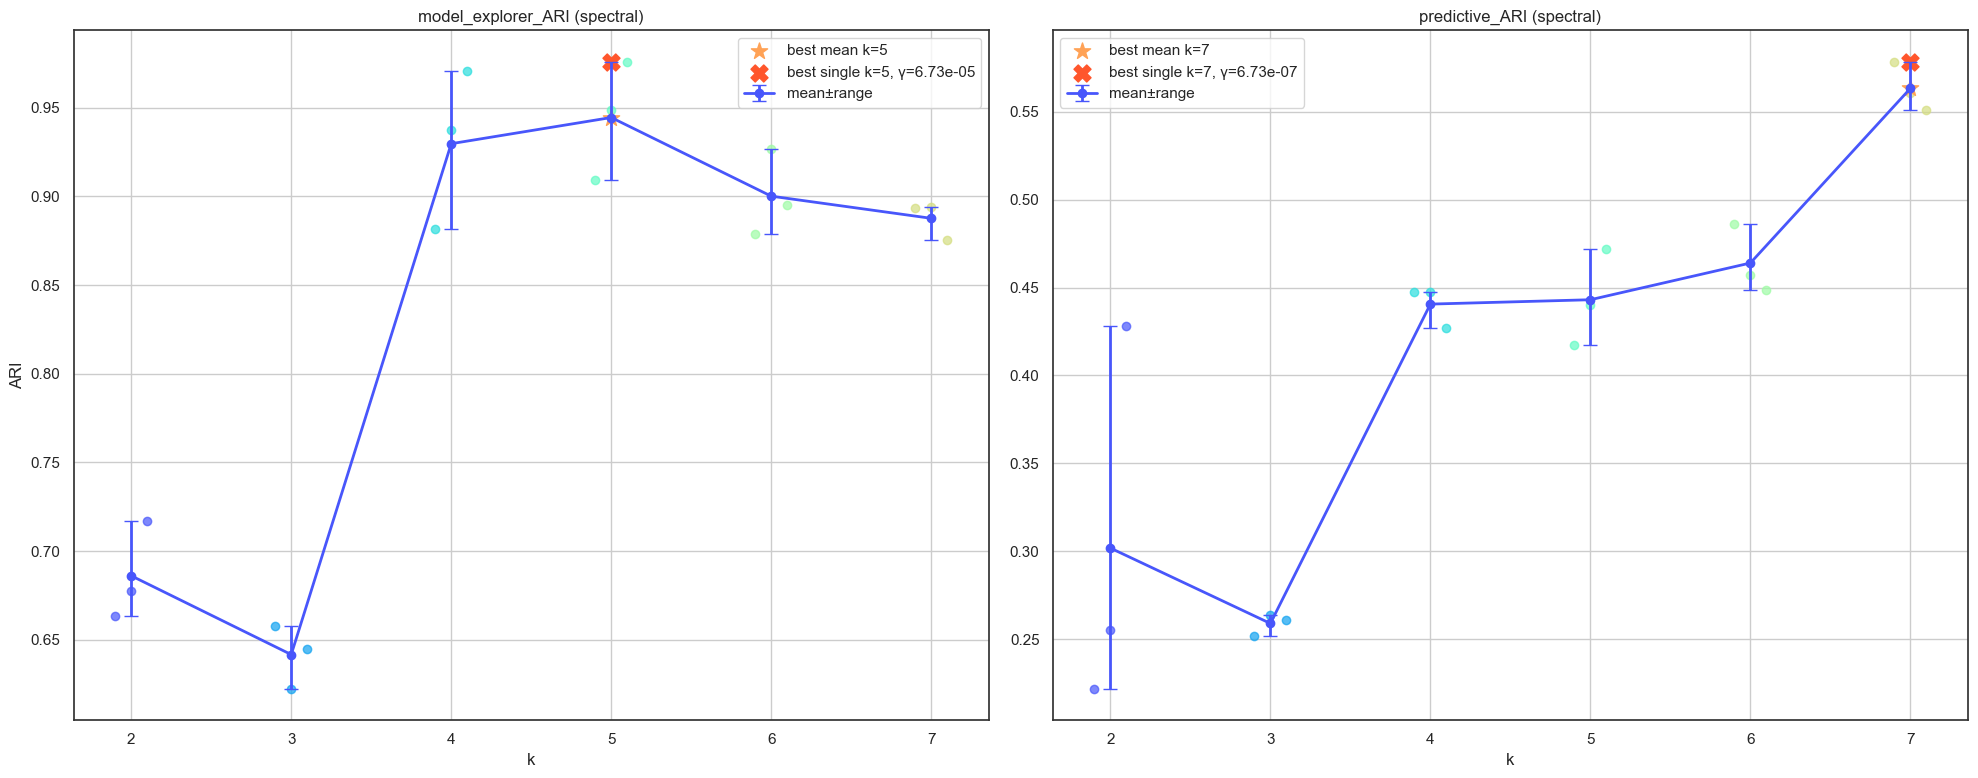

In [133]:
spec = df[df['method'] == 'spectral']
ks = sorted(spec['k'].unique())

mean_model = spec.groupby('k')['model_explorer_ARI'].mean()
min_model  = spec.groupby('k')['model_explorer_ARI'].min()
max_model  = spec.groupby('k')['model_explorer_ARI'].max()
k_best_mean_model = mean_model.idxmax()
best_single_model = spec.loc[spec['model_explorer_ARI'].idxmax()]

mean_pred = spec.groupby('k')['predictive_ARI'].mean()
min_pred  = spec.groupby('k')['predictive_ARI'].min()
max_pred  = spec.groupby('k')['predictive_ARI'].max()
k_best_mean_pred = mean_pred.idxmax()
best_single_pred = spec.loc[spec['predictive_ARI'].idxmax()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharex=True)

for k in ks:
    vals = spec[spec['k'] == k]['model_explorer_ARI'].values
    jitter = np.linspace(-0.1, 0.1, len(vals))
    ax1.scatter(np.full_like(vals, k) + jitter, vals, alpha=0.7)

err_low  = mean_model - min_model
err_high = max_model  - mean_model
ax1.errorbar(ks, mean_model, yerr=[err_low, err_high], fmt='o-', capsize=5, label='mean±range')

ax1.scatter(
    k_best_mean_model, mean_model[k_best_mean_model], 
    s=150, marker='*', label=f'best mean k={k_best_mean_model}'
)

ax1.scatter(
    best_single_model['k'], best_single_model['model_explorer_ARI'], 
    s=150, marker='X',
    label=f'best single k={best_single_model["k"]}, γ={best_single_model["gamma"]:.2e}'
)

ax1.set_title('model_explorer_ARI (spectral)')
ax1.set_xlabel('k')
ax1.set_ylabel('ARI')
ax1.legend()

for k in ks:
    vals = spec[spec['k'] == k]['predictive_ARI'].values
    jitter = np.linspace(-0.1, 0.1, len(vals))
    ax2.scatter(np.full_like(vals, k) + jitter, vals, alpha=0.7)

err_low  = mean_pred - min_pred
err_high = max_pred - mean_pred
ax2.errorbar(ks, mean_pred, yerr=[err_low, err_high], fmt='o-', capsize=5, label='mean±range')

ax2.scatter(
    k_best_mean_pred, mean_pred[k_best_mean_pred], 
    s=150, marker='*', label=f'best mean k={k_best_mean_pred}'
)

ax2.scatter(
    best_single_pred['k'], best_single_pred['predictive_ARI'], 
    s=150, marker='X',
    label=f'best single k={best_single_pred["k"]}, γ={best_single_pred["gamma"]:.2e}'
)

ax2.set_title('predictive_ARI (spectral)')
ax2.set_xlabel('k')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
best_model = df.loc[df['model_explorer_ARI'].idxmax()]
best_pred  = df.loc[df['predictive_ARI'].idxmax()]

print("global best model_explorer_ARI:", best_model.to_dict())

global best model_explorer_ARI: {'method': 'spectral', 'linkage': None, 'gamma': 6.727239749906794e-05, 'k': 5, 'model_explorer_ARI': 0.9759721477067698, 'predictive_ARI': 0.47184639287378455}
global best predictive_ARI: {'method': 'hierarchical', 'linkage': 'ward', 'gamma': nan, 'k': 7, 'model_explorer_ARI': 0.905287524626071, 'predictive_ARI': 0.6022411622035175}


In [136]:
opt_labels = clustering_pipeline(X=X, k=5, cluster_method='spectral', gamma=6.727239749906794e-05)

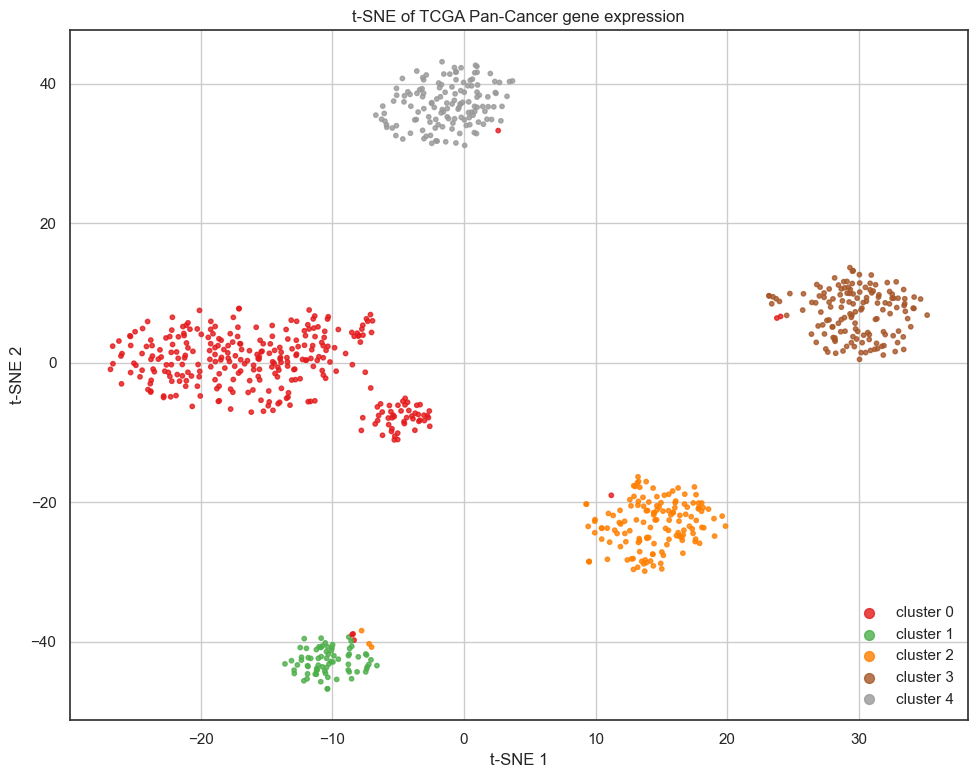

In [138]:
plot_dim_reduced_clustering(X, opt_labels, method='tSNE')

In [145]:
from sklearn.metrics import confusion_matrix, accuracy_score
from scipy.optimize import linear_sum_assignment

def map_clusterings(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    row_idx, col_idx = linear_sum_assignment(-cm)
    return dict(zip(col_idx, row_idx))

mapping = map_clusterings(y, opt_labels)

opt_labels_mapped = np.vectorize(mapping.get)(opt_labels)
print('accuracy:', accuracy_score(y, opt_labels_mapped))

accuracy: 0.9862671660424469
